In [40]:
from ucimlrepo import fetch_ucirepo

bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features
y = bank_marketing.data.targets

print(bank_marketing.metadata)

print("\n")

print(bank_marketing.variables)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

| Nombre de la variable | Tipo | Descripción |
| --- | --- | --- |
| age | Entero | Edad del cliente en años. |
| job | Categórico | Tipo de trabajo del cliente (admin., obrero, jubilado, autónomo, servicios, estudiante, técnico, desempleado, ama de casa, emprendedor, gerencia, desconocido). |
| marital | Categórico | estado civil (casado, soltero, divorciado o viudos) |
| education | Categórico | Nivel educativo alcanzado por el cliente (primario, secundario, terciario, ...) |
| default | Binario | Indica si el cliente tiene un crédito en situación de mora (sí / no) |
| balance | Entero | Saldo promedio anual|
| housing | Binario | ¿Tiene préstamo hipotecario? (sí / no) |
| loan | Binario | ¿Tiene un préstamo personal? (sí / no) |
| contact | Categórico | Medio de comunicación usado en el último contacto (celular, teléfono fijo, ...) |
| day_of_week | Fecha | Último día de contacto de la semana |
| month | Fecha | Mes del año en que se realizó el último contacto (ene, feb, mar, ...) |
| duration | Entero | Duración en segundos de la última llamada de contacto con el cliente |
| campaign | Entero | Número de contactos realizados con el cliente durante la campaña actual (incluye el último) |
| pdays | Entero | Días transcurridos desde el último contacto en una campaña previa (−1 indica que el cliente no fue contactado anteriormente) |
| previous | Entero | Número de contactos realizados con el cliente antes de la campaña actual. |
| poutcome | Categórico |  Resultado de la campaña de marketing anterior (éxito, fracaso, otro) |
| y | Binario | Variable objetivo: indica si el cliente terminó suscribiendo un depósito a plazo fijo (sí / no). |

In [41]:
import pandas as pd
import numpy as np

print(X.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome  
0     NaN            5   may       261         1     -1         0      NaN  
1     NaN            5   may       151         1     -1         0      NaN  
2     NaN            5   may        76         1     -1         0      NaN  
3     NaN            5   may        92         1     -1         0      NaN  
4     NaN            5   may       198         1     -1         0      NaN  


In [42]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   age          45211 non-null  int64
 1   job          44923 non-null  str  
 2   marital      45211 non-null  str  
 3   education    43354 non-null  str  
 4   default      45211 non-null  str  
 5   balance      45211 non-null  int64
 6   housing      45211 non-null  str  
 7   loan         45211 non-null  str  
 8   contact      32191 non-null  str  
 9   day_of_week  45211 non-null  int64
 10  month        45211 non-null  str  
 11  duration     45211 non-null  int64
 12  campaign     45211 non-null  int64
 13  pdays        45211 non-null  int64
 14  previous     45211 non-null  int64
 15  poutcome     8252 non-null   str  
dtypes: int64(7), str(9)
memory usage: 5.5 MB


In [43]:
X.isnull().sum()

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
dtype: int64

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>,
        <Axes: title={'center': 'day_of_week'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'pdays'}>],
       [<Axes: title={'center': 'previous'}>, <Axes: >, <Axes: >]],
      dtype=object)

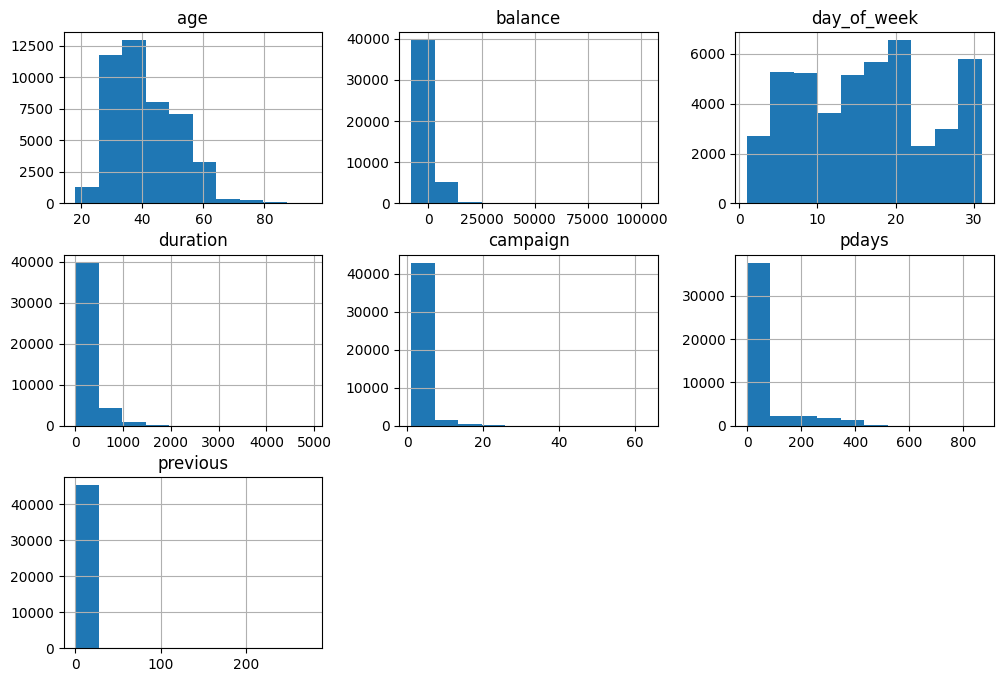

In [44]:
# Histogramas para variables numéricas
X.hist(figsize=(12, 8))

## Preprocesamiento
Reemplazmos los nulos por la moda de cada variable

In [45]:
col_cat = X.select_dtypes(include=['object']).columns
columnas_objetivo = col_cat[X[col_cat].isnull().any()]

for c in columnas_objetivo:
    moda = X[c].mode()[0]
    X[c] = X[c].fillna(moda) # Reemplazamos NaN con la moda

/tmp/ipykernel_26223/3326357307.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col_cat = X.select_dtypes(include=['object']).columns


In [46]:
X.isnull().sum()

age            0
job            0
marital        0
education      0
default        0
balance        0
housing        0
loan           0
contact        0
day_of_week    0
month          0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
dtype: int64

### Codificación binaria y ordinal

- **Binarias** (`default`, `housing`, `loan`, `y`): `yes/no` → `1/0`.
- **Ordinal** (`education`): `primary < secondary < tertiary`.

In [47]:
# Binarias -> 0/1
for col in ['default', 'housing', 'loan']:
    X[col] = (X[col] == 'yes').astype(int)

# Ordinal: education (primary < secondary < tertiary)
edu_map = {'primary': 0, 'secondary': 1, 'tertiary': 2}
X['education'] = X['education'].map(edu_map)

y_bin = (y.values.ravel() == 'yes').astype(int)

print(f"X shape: {X.shape}")
print(f"y_bin shape: {y_bin.shape}")
print(f"\nMuestra de X tras binarizar/ordenar:")
display(X[['default','housing','loan','education']].head())

X shape: (45211, 16)
y_bin shape: (45211,)

Muestra de X tras binarizar/ordenar:


,default,housing,loan,education
0,0,1,0,2
1,0,1,0,1
2,0,1,1,1
3,0,1,0,1
4,0,0,0,1


### División del dataset para entrenamiento y test
Como sabemos, el dataset está desbalanceado: aproximadamente el 88% de los registros tiene predicción "no" y solo el 12% tiene "sí". Si la división train/test se hiciera al azar puro, podríamos terminar con un test que tenga 95% "no" y 5% "sí" (o cualquier otra proporción sesgada), lo que haría que las métricas reportadas no reflejen el rendimiento real del modelo.                   

Para evitar esto, usamos el parámetro `stratify=y_bin` en `train_test_split`. Con esto, sklearn se asegura de que la proporción 88/12 se mantenga igual tanto en el conjunto de entrenamiento como en el de prueba, garantizando que ambos sean representativos del problema real.

El split se realiza **antes** de cualquier transformación con `fit`, usando `stratify=y_bin` para conservar la proporción 88/12 en train y test. El `OneHotEncoder` vive dentro de un `Pipeline` de sklearn — así se ajusta únicamente sobre los datos de entrenamiento durante la validación cruzada y se evita por completo el **data leakage**.

Además, el `class_weight='balanced'` que mencionaba el §6.1 del informe ahora **sí** se aplica realmente en el clasificador.

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Split estrategico 
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=33, stratify=y_bin
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Balance train: {y_train.mean():.3f} positivos  |  Balance test: {y_test.mean():.3f} positivos\n")

Train: (36168, 16)  |  Test: (9043, 16)
Balance train: 0.117 positivos  |  Balance test: 0.117 positivos



Vamos a separar las columnas en 2 grupos:                                                                                                                                                            
  - `cols_cat` — categóricas puras (texto como 'married', 'cellular', 'may'). No tienen orden lógico.
  - `cols_num` — numéricas o binarias (en celdas anteriores convertiste default/housing/loan a 0/1 y education a 0/1/2). 

Además se usa `ColumnTransformer` el cual aplica una transformación distinta a cada grupo de columnas y luego concatena el resultado.
  - A las columnas categóricas (`cols_cat`) les aplica OneHotEncoder -> cada valor único se vuelve una columna binaria. Ejemplo: la columna marital con valores married/single/divorced se convierte en
  3 columnas: marital_married, marital_single, marital_divorced con 0/1.                                                                                                                             
  - `handle_unknown='ignore'`: si en test aparece una categoría que no se vio en train, no se rompe sino la deja en ceros.
  - `sparse_output=False`: devuelve un array denso normal.                                                                                                           
  - `remainder='passthrough'`: las columnas que no nombraste (todas las cols_num) pasan tal cual, sin transformación. Esto tiene sentido porque los árboles no necesitan escalado.

In [49]:
cols_cat = ['job', 'marital', 'contact', 'poutcome', 'month']
cols_num = ['age', 'education', 'default', 'balance', 'housing', 'loan',
            'day_of_week', 'duration', 'campaign', 'pdays', 'previous']

preprocesador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_cat),
    ],
    remainder='passthrough'
)

Acá realiza un Pipeline. Es decir cuando se entrena, sklearn ejecuta cada paso en orden:                                                                                                        
                                          
  X_train  ->  [prep: ColumnTransformer]  ->  X_train_numérico  ->  [clf: RandomForest]  ->  modelo entrenado                                                                                            
                                                                                                                                                                                                     
  Cada paso es una tupla (nombre, objeto):    
  - `'prep'` -> el ColumnTransformer que se armo en el paso anterior                                                                                                                                          
  - `'clf'` -> el RandomForest con:                                                                                                                                                                     
    - `random_state=30` -> es la "semilla" del azar
    - `class_weight='balanced'` -> penaliza más fuerte los errores en la clase minoritaria (los "sí"), para que el modelo no ignore al 12% que es lo importante.                                        

In [50]:
pipeline_base = Pipeline([
    ('prep', preprocesador),
    ('clf', RandomForestClassifier(random_state=30, class_weight='balanced', n_jobs=-1))
])
print("Pipeline base construido:")
print(pipeline_base)

Pipeline base construido:
Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['job', 'marital', 'contact',
                                                   'poutcome', 'month'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=30))])


## Árbol de decisión

Antes de pasar al Random Forest, entrenamos **un único árbol CART** con profundidad limitada (`max_depth=4`) y lo visualizamos. Esto nos sirve como referencia base, el RF debe superarlo claramente y muestra de forma transparente cómo el algoritmo particiona el espacio.

In [51]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import f1_score

dt_pipeline = Pipeline([
    ('prep', preprocesador),
    ('clf', DecisionTreeClassifier(max_depth=4, criterion='gini',
                                    class_weight='balanced', random_state=30))
])
dt_pipeline.fit(X_train, y_train)

f1_train = f1_score(y_train, dt_pipeline.predict(X_train))
f1_test  = f1_score(y_test,  dt_pipeline.predict(X_test))
print(f"F1 (train) = {f1_train:.4f}")
print(f"F1 (test)  = {f1_test:.4f}")

F1 (train) = 0.4687
F1 (test)  = 0.4670


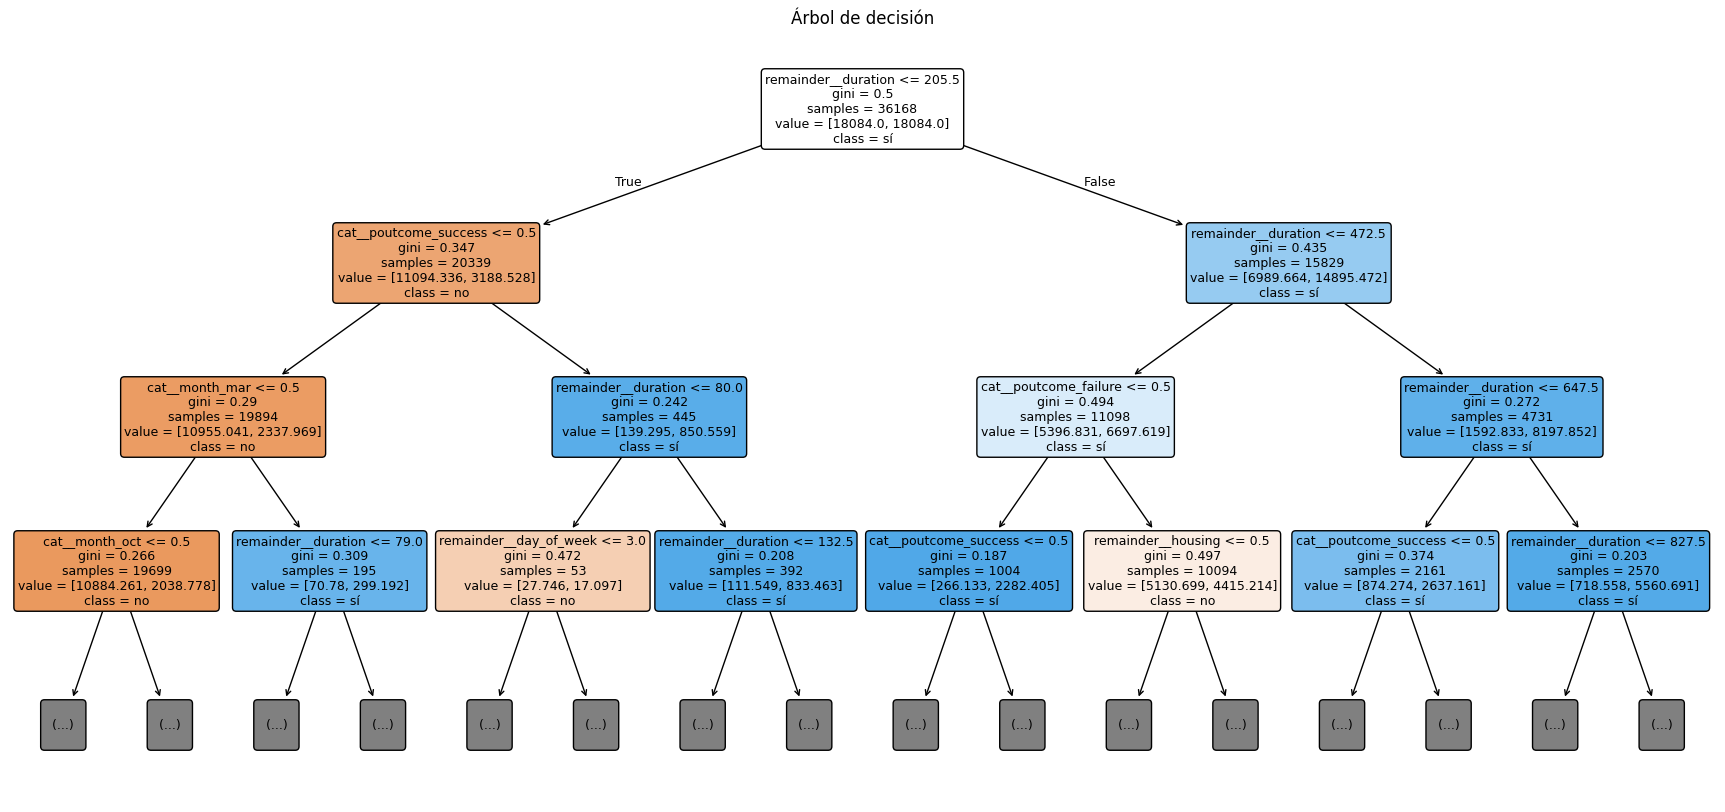

In [52]:
feature_names = dt_pipeline.named_steps['prep'].get_feature_names_out()

plt.figure(figsize=(22, 10))
plot_tree(
    dt_pipeline.named_steps['clf'],
    feature_names=feature_names,
    class_names=['no', 'sí'],
    filled=True, rounded=True, max_depth=3, fontsize=9
)
plt.title("Árbol de decisión")
plt.show()

## Curva OOB: optimización del número de árboles

El **Out-of-Bag error** aprovecha que cada árbol solo ve ≈ 63.2 % de los datos por el bootstrap, el resto sirve como un set de validación "gratis". Graficar OOB error vs `n_estimators` identifica el punto donde añadir árboles deja de aportar y se vuelve costo computacional puro.


In [53]:
X_train_prep = preprocesador.fit_transform(X_train)

n_grid = [25, 50, 100, 200, 300, 500, 800]
oob_errors = []

for n in n_grid:
    rf = RandomForestClassifier(
        n_estimators=n, oob_score=True, bootstrap=True,
        class_weight='balanced', random_state=30, n_jobs=-1
    )
    rf.fit(X_train_prep, y_train)
    err = 1 - rf.oob_score_
    oob_errors.append(err)
    print(f"  n_estimators={n:>4}  →  OOB error = {err:.4f}")

/home/vssz/UTEC/5to/opti/proyect-opti/.venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


  n_estimators=  25  →  OOB error = 0.1573


/home/vssz/UTEC/5to/opti/proyect-opti/.venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


  n_estimators=  50  →  OOB error = 0.1469


/home/vssz/UTEC/5to/opti/proyect-opti/.venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


...

  n_estimators= 200  →  OOB error = 0.1228


/home/vssz/UTEC/5to/opti/proyect-opti/.venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


  n_estimators= 300  →  OOB error = 0.1180


/home/vssz/UTEC/5to/opti/proyect-opti/.venv/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


  n_estimators= 500  →  OOB error = 0.1141
  n_estimators= 800  →  OOB error = 0.1107


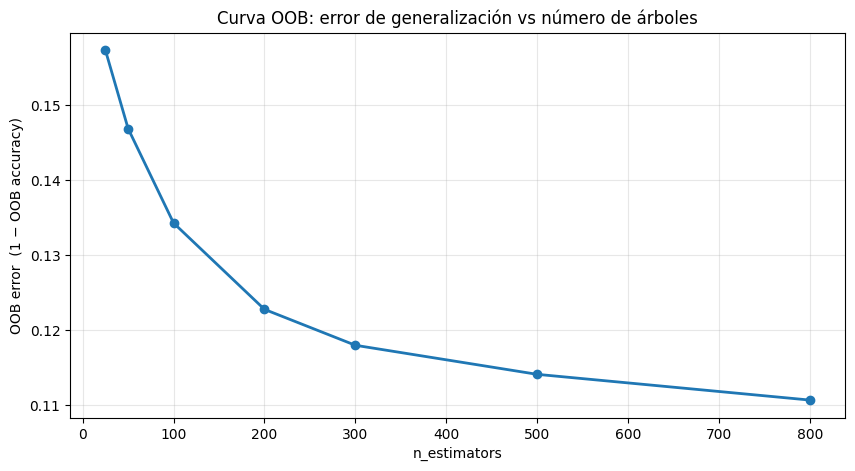

In [54]:
plt.figure(figsize=(10, 5))
plt.plot(n_grid, oob_errors, marker='o', linewidth=2)
plt.xlabel('n_estimators')
plt.ylabel('OOB error  (1 − OOB accuracy)')
plt.title('Curva OOB: error de generalización vs número de árboles')
plt.grid(True, alpha=0.3)
plt.show()

In [55]:
n_opt = n_grid[int(np.argmin(oob_errors))]
print(f"\nÓptimo según OOB: n_estimators = {n_opt}  (error = {min(oob_errors):.4f})")


Óptimo según OOB: n_estimators = 800  (error = 0.1107)


## Optimización manual: coordinate descent sobre hiperparámetros

En lugar de `GridSearchCV` (que sería exhaustivo y costoso), implementamos un **algoritmo iterativo de búsqueda local** sobre el espacio alpha= {`n_estimators`, `max_depth`, `max_features`, `min_samples_split`}:

1. Partir de una configuración inicial alpha'.
2. En cada pasada, fijar todos los hiperparámetros menos uno y barrer sus candidatos.
3. Aceptar el valor que maximiza el **F1 promedio sobre `StratifiedKFold(k=3)`**.
4. Repetir hasta que ninguna coordenada mejore (convergencia).

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Espacio de búsqueda
espacio = {
    'n_estimators':      [100, 200, n_opt, 500],
    'max_depth':         [5, 10, 15, 20, None],
    'max_features':      ['sqrt', 'log2', 0.5],
    'min_samples_split': [2, 5, 10, 20]
}

# Configuración inicial
config = {
    'n_estimators': 200,
    'max_depth': 10,
    'max_features': 'sqrt',
    'min_samples_split': 5
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=30)

def evaluar(cfg):
    pipe = Pipeline([
        ('prep', preprocesador),
        ('clf', RandomForestClassifier(**cfg, class_weight='balanced',
                                        random_state=30, n_jobs=-1))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

mejor_f1 = evaluar(config)
print(f"Configuración inicial: {config}")
print(f"  F1 (CV) inicial = {mejor_f1:.4f}\n")
print("Iniciando coordinate descent...\n")

historia = [(dict(config), mejor_f1)]
max_pasadas = 3

for pasada in range(max_pasadas):
    mejora_en_pasada = False
    for hp, candidatos in espacio.items():
        # Buscar el mejor valor para `hp` manteniendo el resto fijo
        resultados_hp = []
        for v in candidatos:
            cfg_test = dict(config); cfg_test[hp] = v
            f1 = evaluar(cfg_test)
            resultados_hp.append((v, f1))
        v_opt, f1_opt = max(resultados_hp, key=lambda x: x[1])

        if f1_opt > mejor_f1 + 1e-4:
            print(f"  pasada {pasada} | {hp}: {config[hp]} -> {v_opt}  " f"(F1 {mejor_f1:.4f} -> {f1_opt:.4f})")
            config[hp] = v_opt
            mejor_f1 = f1_opt
            mejora_en_pasada = True
            historia.append((dict(config), mejor_f1))
    if not mejora_en_pasada:
        print(f"  pasada {pasada} | sin mejora — convergencia alcanzada")
        break

print(f"\nAlpha' (óptimo encontrado): {config}")
print(f"F1 (CV) óptimo: {mejor_f1:.4f}")

Configuración inicial: {'n_estimators': 200, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5}
  F1 (CV) inicial = 0.5561

Iniciando coordinate descent...

  pasada 0 | n_estimators: 200 -> 500  (F1 0.5561 -> 0.5566)
  pasada 0 | max_depth: 10 -> None  (F1 0.5566 -> 0.6035)


## Evaluación final en el test set

Reentrenamos el RF con Alpha' sobre todo el set de entrenamiento y evaluamos una sola vez sobre el test (que nunca se tocó durante la optimización). Reportamos matriz de confusión, classification report, curva ROC y curva Precision-Recall.

              precision    recall  f1-score   support

          no       0.97      0.91      0.94      7985
          sí       0.52      0.77      0.62      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.84      0.78      9043
weighted avg       0.91      0.89      0.90      9043



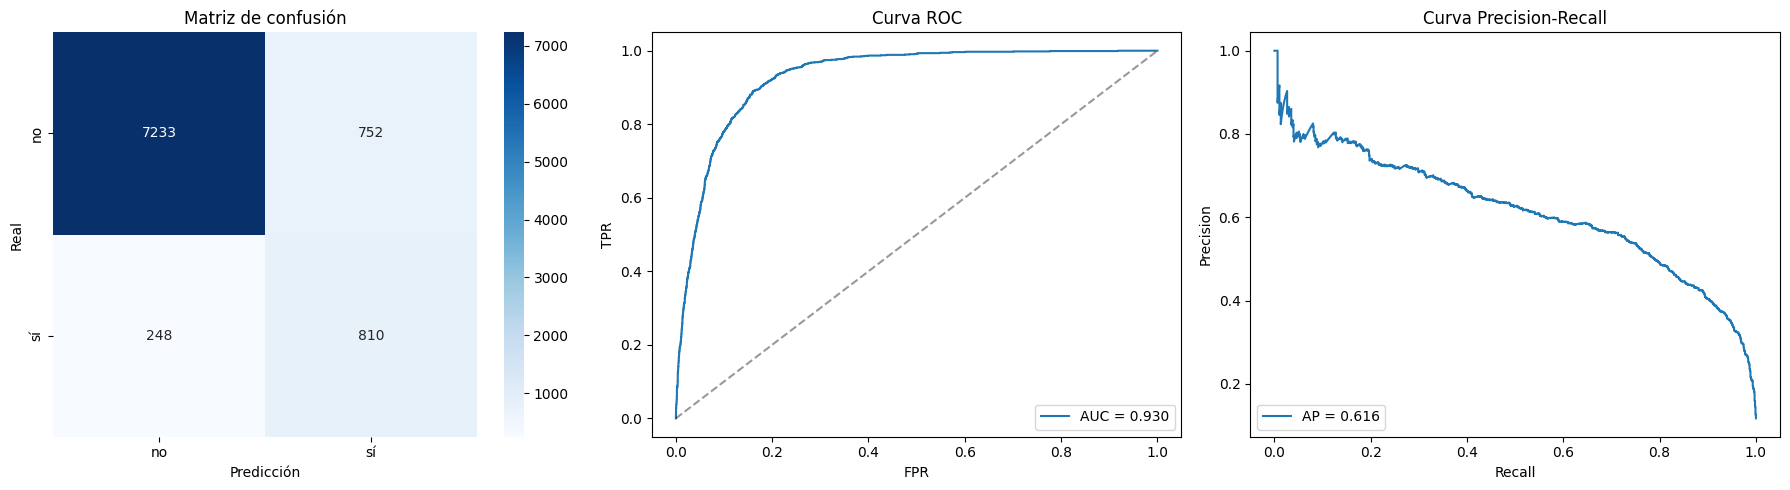

In [ ]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_curve, average_precision_score,
                              roc_curve, auc)

modelo_final = Pipeline([
    ('prep', preprocesador),
    ('clf', RandomForestClassifier(**config, class_weight='balanced',
                                    random_state=30, n_jobs=-1))
])
modelo_final.fit(X_train, y_train)

y_pred = modelo_final.predict(X_test)
y_prob = modelo_final.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['no', 'sí']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['no', 'sí'], yticklabels=['no', 'sí'])
axes[0].set_title('Matriz de confusión')
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right')

# Curva Precision-Recall (más informativa con desbalance)
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
axes[2].plot(rec, prec, label=f'AP = {ap:.3f}')
axes[2].set_title('Curva Precision-Recall')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower left')

plt.tight_layout()
plt.show()

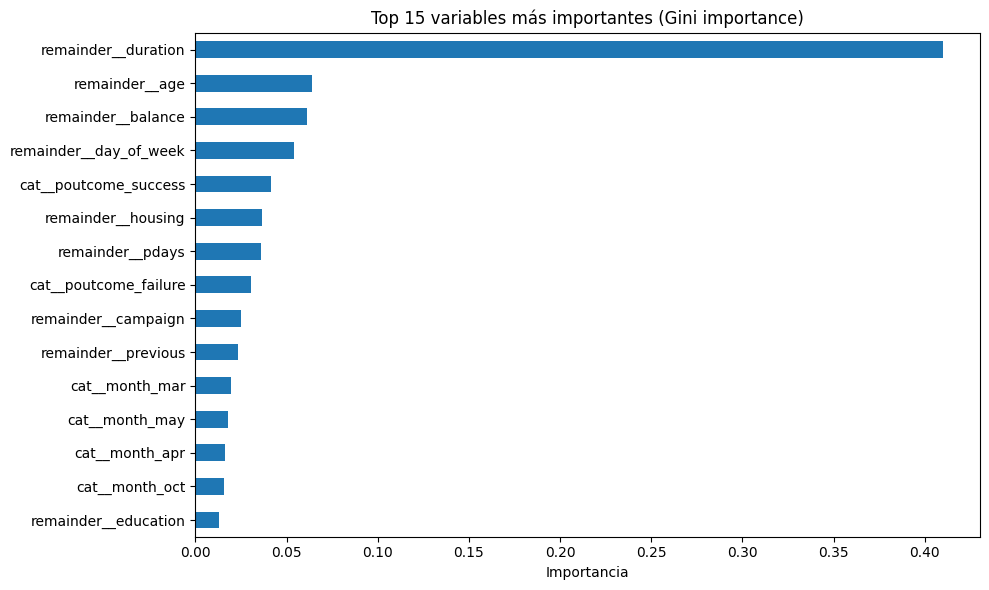

In [ ]:
# Importancia de variables del modelo final
feature_names = modelo_final.named_steps['prep'].get_feature_names_out()
importancias = pd.Series(
    modelo_final.named_steps['clf'].feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
importancias[::-1].plot.barh()
plt.title('Top 15 variables más importantes (Gini importance)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

## Persistencia del modelo y demo de predicción

Guardamos el pipeline completo (preprocesamiento + RF) con `joblib`. La función `predecir_cliente` recibe un dict con los datos del cliente y devuelve la probabilidad de suscripción más la decisión binaria — el pipeline cargado ya incluye toda la cadena de transformaciones, así que no hay que repetir encoding manual.

In [61]:
import joblib

joblib.dump(modelo_final, 'modelo_final.joblib')
print("Modelo guardado en modelo_final.joblib")


def predecir_cliente(cliente: dict, umbral: float = 0.5, ruta: str = 'modelo_final.joblib'):
    pipe = joblib.load(ruta)
    df = pd.DataFrame([cliente])

    bin_map = {'yes': 1, 'no': 0}
    for col in ['default', 'housing', 'loan']:
        df[col] = df[col].replace(bin_map).astype(int)

    edu_map = {'primary': 0, 'secondary': 1, 'tertiary': 2, 'unknown': 1}
    df['education'] = df['education'].replace(edu_map).astype(int)

    prob = float(pipe.predict_proba(df)[0, 1])
    pred = 'sí suscribe' if prob >= umbral else 'no suscribe'
    return {'probabilidad': prob, 'prediccion': pred}

Modelo guardado en modelo_final.joblib


In [68]:
nuevo_cliente = {
    'age': 35, 'job': 'technician', 'marital': 'married', 'education': 'tertiary',
    'default': 'no', 'balance': 1500, 'housing': 'yes', 'loan': 'no',
    'contact': 'cellular', 'day_of_week': 15, 'month': 'may',
    'duration': 320, 'campaign': 2, 'pdays': -1, 'previous': 0,
    'poutcome': 'unknown'
}

resultado1 = predecir_cliente(nuevo_cliente)
print("Cliente nuevo:")
for k, v in nuevo_cliente.items():
    print(f"  {k:>12}: {v}")
print(f"\n-> Probabilidad de suscribir: {resultado1['probabilidad']:.2%}")
print(f"-> Predicción:               {resultado1['prediccion']}")


Cliente nuevo:
           age: 35
           job: technician
       marital: married
     education: tertiary
       default: no
       balance: 1500
       housing: yes
          loan: no
       contact: cellular
   day_of_week: 15
         month: may
      duration: 320
      campaign: 2
         pdays: -1
      previous: 0
      poutcome: unknown

-> Probabilidad de suscribir: 16.58%
-> Predicción:               no suscribe


In [69]:
cliente_facil_si = {                                                                                                                                                                               
    'age': 65, 'job': 'retired', 'marital': 'married', 'education': 'tertiary',                                                                                                                    
    'default': 'no', 'balance': 5000, 'housing': 'no', 'loan': 'no',                                                                                                                               
    'contact': 'cellular', 'day_of_week': 15, 'month': 'mar',                                                                                                                                      
    'duration': 800, 'campaign': 1, 'pdays': 30, 'previous': 2,                                                                                                                                    
    'poutcome': 'success'                                                                                                                                     
}  

resultado2 = predecir_cliente(cliente_facil_si)
print("Cliente fácil (sí):")
for k, v in cliente_facil_si.items():
    print(f"  {k:>12}: {v}")
print(f"\n-> Probabilidad de suscribir: {resultado2['probabilidad']:.2%}")
print(f"-> Predicción:               {resultado2['prediccion']}")

Cliente fácil (sí):
           age: 65
           job: retired
       marital: married
     education: tertiary
       default: no
       balance: 5000
       housing: no
          loan: no
       contact: cellular
   day_of_week: 15
         month: mar
      duration: 800
      campaign: 1
         pdays: 30
      previous: 2
      poutcome: success

-> Probabilidad de suscribir: 87.39%
-> Predicción:               sí suscribe


In [70]:

cliente_interesado = {                                                                                                                                                                             
    'age': 22, 'job': 'student', 'marital': 'single', 'education': 'tertiary',                                                                                                                     
    'default': 'no', 'balance': 200, 'housing': 'no', 'loan': 'no',                                                                                                                                
    'contact': 'cellular', 'day_of_week': 10, 'month': 'oct',                                                                                                                                    
    'duration': 1200, 'campaign': 1, 'pdays': -1, 'previous': 0,                                                                                                                                   
    'poutcome': 'unknown'                   
} 

resultado3 = predecir_cliente(cliente_interesado)
print("Cliente interesado:")
for k, v in cliente_interesado.items():
    print(f"  {k:>12}: {v}")
print(f"\n-> Probabilidad de suscribir: {resultado3['probabilidad']:.2%}")
print(f"-> Predicción:               {resultado3['prediccion']}")

Cliente interesado:
           age: 22
           job: student
       marital: single
     education: tertiary
       default: no
       balance: 200
       housing: no
          loan: no
       contact: cellular
   day_of_week: 10
         month: oct
      duration: 1200
      campaign: 1
         pdays: -1
      previous: 0
      poutcome: unknown

-> Probabilidad de suscribir: 68.05%
-> Predicción:               sí suscribe


In [71]:
cliente_facil_no = {                                                                                                                                                                               
    'age': 45, 'job': 'blue-collar', 'marital': 'married', 'education': 'primary',
    'default': 'yes', 'balance': -500, 'housing': 'yes', 'loan': 'yes',                                                                                                                            
    'contact': 'unknown', 'day_of_week': 5, 'month': 'may',                                                                                                                                      
    'duration': 30, 'campaign': 8, 'pdays': -1, 'previous': 0,                                                                                                                                     
    'poutcome': 'failure'               
} 

resultado4 = predecir_cliente(cliente_facil_no)
print("Cliente fácil (no):")
for k, v in cliente_facil_no.items():
    print(f"  {k:>12}: {v}")
print(f"\n-> Probabilidad de suscribir: {resultado4['probabilidad']:.2%}")
print(f"-> Predicción:               {resultado4['prediccion']}")

Cliente fácil (no):
           age: 45
           job: blue-collar
       marital: married
     education: primary
       default: yes
       balance: -500
       housing: yes
          loan: yes
       contact: unknown
   day_of_week: 5
         month: may
      duration: 30
      campaign: 8
         pdays: -1
      previous: 0
      poutcome: failure

-> Probabilidad de suscribir: 2.15%
-> Predicción:               no suscribe
